In [40]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import gc

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Data Preparation & EDA

In [41]:
# Read dataset
behaviors = pd.read_csv(
    "/content/drive/MyDrive/Y4S1/BT4222/MINDsmall_train/behaviors.tsv",
    sep="\t",
    header=None,
    names=[
        "impression_id",
        "user_id",
        "time",
        "history",
        "impressions"
    ]
)
behaviors["time"] = pd.to_datetime(
    behaviors["time"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

In [42]:
# Explore behaviors dataset
print("Impressions (rows):", len(behaviors))
print("Users:", behaviors["user_id"].nunique())
print("Time range:", behaviors["time"].min(), "to", behaviors["time"].max())
print("Unparsed timestamps:", behaviors["time"].isna().sum())
print("Missing impression lists:", behaviors["impressions"].isna().sum())
behaviors.head()

Impressions (rows): 156965
Users: 50000
Time range: 2019-11-09 00:00:19 to 2019-11-14 23:59:13
Unparsed timestamps: 0
Missing impression lists: 0


,impression_id,user_id,time,history,impressions
0,1,U13740,2019-11-11 09:05:58,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,2019-11-12 18:11:30,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,2019-11-14 07:01:48,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,2019-11-11 05:28:05,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,2019-11-12 16:11:21,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [43]:
# Prepare impressions dataset
impressions = (
    behaviors[
        [
            "impression_id",
            "user_id",
            "time",
            "impressions"
        ]
    ]
    .assign(
        impression_item=lambda df: (
            df["impressions"]
            .astype(str)
            .str.split()
        ) # Split impressions into lists of "new_id-clicked" strings
    )
    .explode("impression_item") # Each news id in a separate row
    .drop(columns="impressions")
)

impressions["news_id"] = (
    impressions["impression_item"]
    .str.rsplit("-", n=1)
    .str[0]
)

impressions["clicked"] = (
    impressions["impression_item"]
    .str.rsplit("-", n=1)
    .str[1]
    .astype("int8")
)


In [44]:
# Explore impressions dataset
print("Article exposure records:", len(impressions))
print("Unique clicked values:", impressions["clicked"].unique()) # Check valid clicked values (0 or 1)
impressions.head()

Article exposure records: 5843444
Unique clicked values: [1 0]


,impression_id,user_id,time,impression_item,news_id,clicked
0,1,U13740,2019-11-11 09:05:58,N55689-1,N55689,1
0,1,U13740,2019-11-11 09:05:58,N35729-0,N35729,0
1,2,U91836,2019-11-12 18:11:30,N20678-0,N20678,0
1,2,U91836,2019-11-12 18:11:30,N39317-0,N39317,0
1,2,U91836,2019-11-12 18:11:30,N58114-0,N58114,0


## 1. Slate Length

In [45]:
# Get slate-level summary (one row per impression_id)
slate_summary = (
    impressions
    .groupby("impression_id")
    .agg(
        slate_length=("news_id", "size"),
        clicks=("clicked", "sum")
    )
    .reset_index()
)

# Attach slate length to impressions dataset
impressions["slate_length"] = (
    impressions["impression_id"]
    .map(slate_summary.set_index("impression_id")["slate_length"])
    .astype("int16")
)

In [46]:
# Explore slate length
print("Impressions:", len(slate_summary)) # Check that it matches behaviors dataset
slate_summary[["slate_length"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

Impressions: 156965


,slate_length
count,156965.000000
mean,37.227688
std,38.594148
min,2.000000
5%,2.000000
25%,10.000000
50%,24.000000
75%,51.000000
90%,91.000000
95%,118.000000


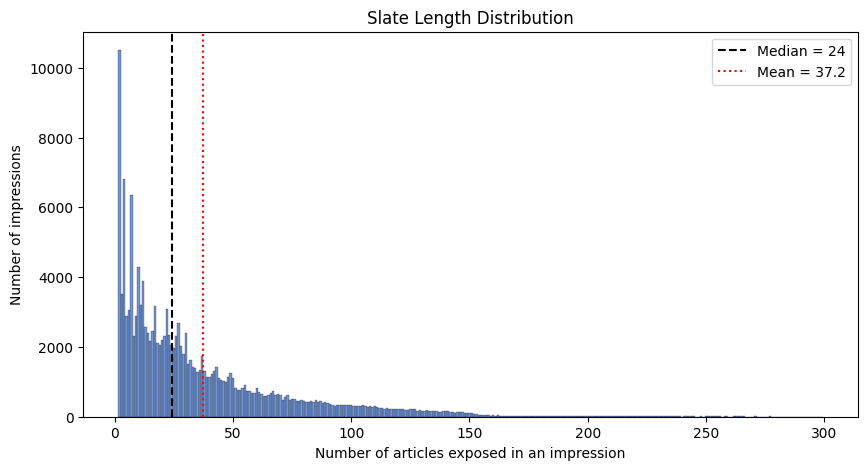

In [47]:
# Plot slate length distribution
mean_len = slate_summary["slate_length"].mean()
median_len = slate_summary["slate_length"].median()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=slate_summary,
    x="slate_length",
    discrete=True,
    color="#4472C4",
    ax=ax,
)
ax.set_title(f"Slate Length Distribution")
ax.axvline(median_len, color="black", linestyle="--", label=f"Median = {median_len:.0f}")
ax.axvline(mean_len, color="red", linestyle=":", label=f"Mean = {mean_len:.1f}")
ax.set_xlabel("Number of articles exposed in an impression")
ax.set_ylabel("Number of impressions")
ax.legend()
plt.show()

## 2. Impression-Level Clicks

In [56]:
click_summary = (
    slate_summary["clicks"]
    .value_counts()
    .sort_index()
    .rename_axis("clicks")
    .reset_index(name="number_of_impressions")
)

click_summary["percentage"] = (
    click_summary["number_of_impressions"]
    / click_summary["number_of_impressions"].sum()
    * 100
)

click_summary["percentage"] = click_summary["percentage"].round(2)

click_summary

,clicks,number_of_impressions,percentage
0,1,113888,72.56
1,2,25571,16.29
2,3,9263,5.90
3,4,3975,2.53
4,5,1957,1.25
5,6,942,0.60
6,7,515,0.33
7,8,296,0.19
8,9,198,0.13
9,10,117,0.07


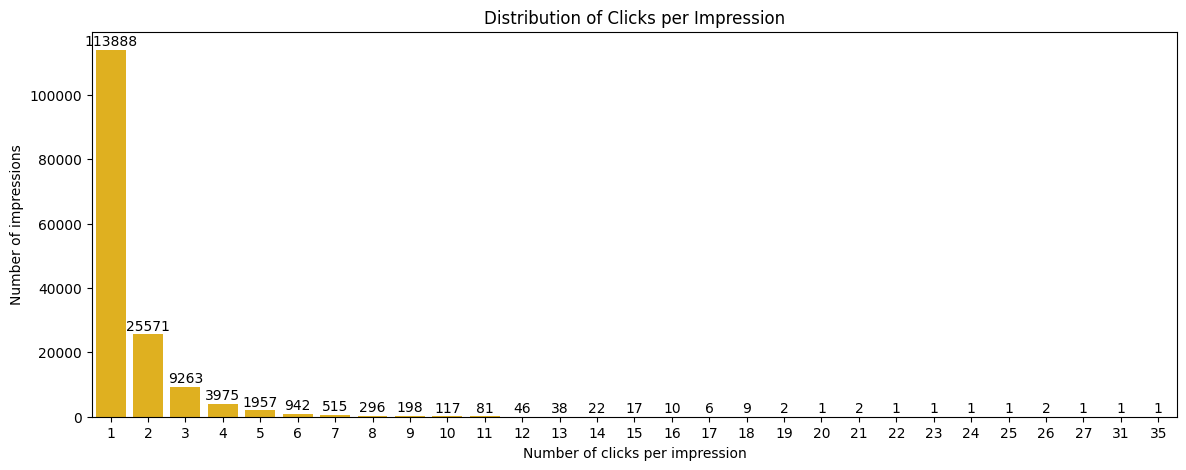

In [61]:
plt.figure(figsize=(14, 5))

ax = sns.barplot(
    data=click_summary,
    x="clicks",
    y="number_of_impressions",
    color="#FFC000"
)

# Add count labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=1
    )

plt.xlabel("Number of clicks per impression")
plt.ylabel("Number of impressions")
plt.title("Distribution of Clicks per Impression")
plt.show()

In [ ]:
# Plot does not show 0 clicks - Confirm if there are any impressions with no clicks
print("Impressions with no click:", (slate_summary["clicks"] == 0).sum()) 

Impressions with no click: 0


## 3. Exposure-Level CTR

In [50]:
print("Clicked exposures:", impressions["clicked"].sum())
print("Unclicked exposures:", (impressions["clicked"] == 0).sum())
print("Exposure-level CTR:", impressions["clicked"].mean())

Clicked exposures: 236344
Unclicked exposures: 5607100
Exposure-level CTR: 0.040446010948338


## 4. CTR Across Slate Length

In [51]:
# Slate-length level summary
slate_length_summary = (
    slate_summary
    .groupby("slate_length")
    .agg(
        impressions=("impression_id", "size"),
        total_clicks=("clicks", "sum"),
    )
    .reset_index()
)

slate_length_summary["exposures"] = (
    slate_length_summary["slate_length"] * slate_length_summary["impressions"]
)
slate_length_summary["exposure_level_ctr"] = (
    slate_length_summary["total_clicks"] / slate_length_summary["exposures"]
)
slate_length_summary["min_ctr"] = 1 / slate_length_summary["slate_length"]
slate_length_summary["excess_over_min"] = (
    slate_length_summary["exposure_level_ctr"] - slate_length_summary["min_ctr"]
)

pd.concat([
    slate_length_summary.head(5),
    slate_length_summary.tail(5)
])

,slate_length,impressions,total_clicks,exposures,exposure_level_ctr,min_ctr,excess_over_min
0,2,10509,10509,21018,0.500000,0.500000,0.000000
1,3,3504,3544,10512,0.337139,0.333333,0.003805
2,4,6809,7036,27236,0.258335,0.250000,0.008335
3,5,2889,3001,14445,0.207754,0.200000,0.007754
4,6,3053,3270,18318,0.178513,0.166667,0.011846
291,293,1,3,293,0.010239,0.003413,0.006826
292,294,4,8,1176,0.006803,0.003401,0.003401
293,295,2,3,590,0.005085,0.003390,0.001695
294,297,1,1,297,0.003367,0.003367,0.000000
295,299,1,2,299,0.006689,0.003344,0.003344


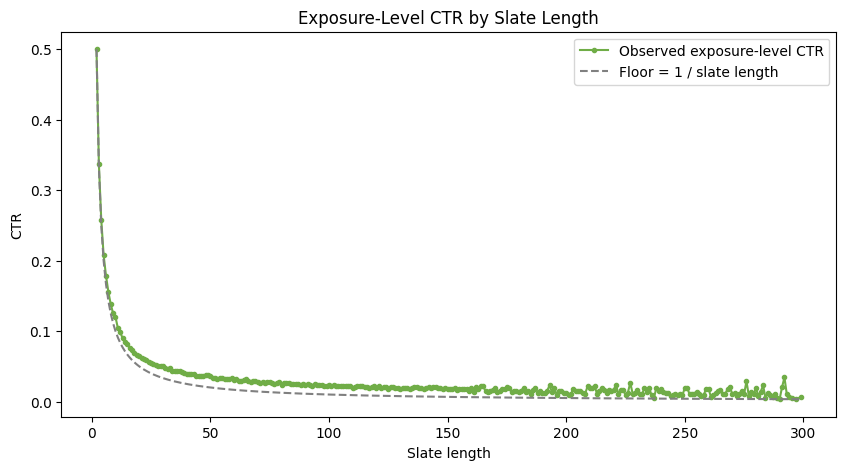

In [52]:
# Plot observed CTR vs the 1/L floor 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(slate_length_summary["slate_length"], slate_length_summary["exposure_level_ctr"],
        marker="o", markersize=3, color="#70AD47", label="Observed exposure-level CTR")
ax.plot(slate_length_summary["slate_length"], slate_length_summary["min_ctr"],
        linestyle="--", color="grey", label="Floor = 1 / slate length")
ax.set_title(f"Exposure-Level CTR by Slate Length")
ax.set_xlabel("Slate length")
ax.set_ylabel("CTR")
ax.legend()
plt.show()